In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Load Dataset

In [2]:

df = pd.read_csv("../data/raw/application_train.csv")

print(df.shape)

df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Basic Cleaning

In [3]:
# Replace placeholder value
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

## Feature Engineering

In [4]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365

df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

df["CREDIT_GOODS_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
)

df["INCOME_PER_FAMILY"] = (
    df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
)

df["CREDIT_PER_FAMILY"] = (
    df["AMT_CREDIT"] / df["CNT_FAM_MEMBERS"]
)

df["EMPLOYMENT_AGE_RATIO"] = (
    df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]
)

In [5]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (307511, 129)
y Shape: (307511,)


## Train-Test Split

Split the dataset while preserving the target class distribution.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (246008, 129)
Test : (61503, 129)


## Identify Feature Types

Separate numerical and categorical features for preprocessing.


In [7]:
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X_train.select_dtypes(
    include="object"
).columns

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Numerical: 113
Categorical: 16


## Build Preprocessing Pipeline

- Numerical: Median Imputation
- Categorical: Most Frequent Imputation + One-Hot Encoding

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Create Model Pipeline

Utility function to combine preprocessing with any machine learning model.

In [9]:
def build_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

In [10]:
lr_model = build_pipeline(LogisticRegression(...))

rf_model = build_pipeline(RandomForestClassifier(...))

## Model Evaluation

Evaluate a trained model using standard classification metrics.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

## Logistic Regression

Accuracy : 0.6088
Precision: 0.1134
Recall   : 0.5644
F1 Score : 0.1889
ROC AUC  : 0.6185


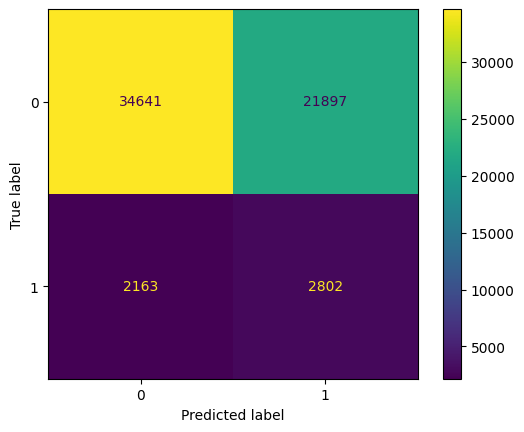

In [12]:
lr_model = build_pipeline(
    LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    )
)

lr_model.fit(X_train, y_train)

evaluate_model(lr_model, X_test, y_test)

## Random Forest

Accuracy : 0.9194
Precision: 1.0000
Recall   : 0.0014
F1 Score : 0.0028
ROC AUC  : 0.7105


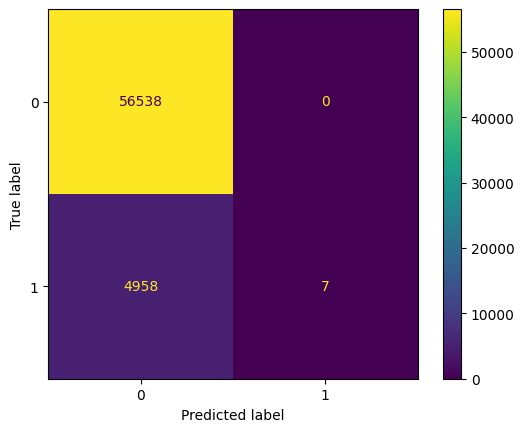

In [13]:
rf_model = build_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test)

## Cross Validation

Cross-validation evaluates the model on multiple train-validation splits.

This provides a more reliable estimate of performance than a single train-test split.

In [14]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    build_pipeline(
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        )
    ),
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC Scores:", cv_scores)
print("Average ROC-AUC:", cv_scores.mean())

ROC-AUC Scores: [0.63194813 0.61796315 0.62197791 0.61975504 0.62591209]
Average ROC-AUC: 0.6235112639405682


## Hyperparameter Tuning

Use Randomized Search with cross-validation to find better Random Forest parameters.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

In [16]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10]
}

In [17]:
rf_search = RandomizedSearchCV(
    estimator=build_pipeline(
        RandomForestClassifier(random_state=42, n_jobs=-1)
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

In [18]:
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'A...
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object'))])),
                                             ('classifier',
                                              RandomForestClassifier(n_jobs=-1,
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [5, 10, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='roc_auc')

In [19]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest ROC-AUC:")
print(rf_search.best_score_)

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_depth': 10}

Best ROC-AUC:
0.7327650101640621


Accuracy : 0.9193
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC AUC  : 0.7382


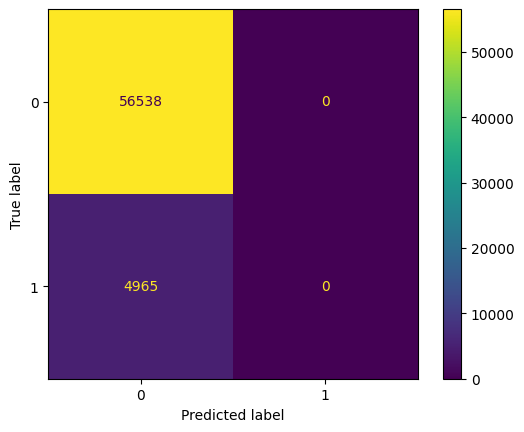

In [20]:
best_rf = rf_search.best_estimator_

evaluate_model(best_rf, X_test, y_test)

## XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm that builds decision trees sequentially.

Each new tree focuses on correcting the errors made by the previous trees, often achieving higher accuracy than Random Forest on tabular datasets.

In [21]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [22]:
from xgboost import XGBClassifier

In [23]:
from xgboost import XGBClassifier

In [24]:
xgb_model = build_pipeline(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
)

In [25]:
xgb_model = build_pipeline(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
)

In [26]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
       ...
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy : 0.9195
Precision: 0.5213
Recall   : 0.0419
F1 Score : 0.0776
ROC AUC  : 0.7503


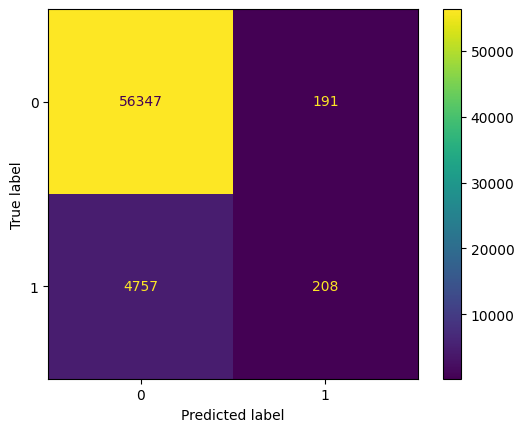

In [27]:
evaluate_model(xgb_model, X_test, y_test)

In [28]:
def compare_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

    results_df = pd.DataFrame(results)

    return results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    ).reset_index(drop=True)

In [29]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Tuned Random Forest": best_rf,
    "XGBoost": xgb_model
}

In [30]:
comparison_df = compare_models(
    models,
    X_test,
    y_test
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.919549,0.521303,0.041893,0.077554,0.750283
1,Tuned Random Forest,0.919272,0.000000,0.000000,0.000000,0.738232
2,Random Forest,0.919386,1.000000,0.001410,0.002816,0.710536
3,Logistic Regression,0.608800,0.113446,0.564350,0.188916,0.618452


## Model Comparison Summary

### Best Model: XGBoost

| Model | ROC-AUC |
|--------|---------|
| Logistic Regression | 0.618 |
| Random Forest | 0.711 |
| Tuned Random Forest | 0.738 |
| XGBoost | **0.751** |

### Key Takeaways

- XGBoost achieved the highest ROC-AUC.
- Hyperparameter tuning improved Random Forest performance.
- Feature engineering improved overall model quality.
- Accuracy alone was misleading because of class imbalance.
- ROC-AUC was the primary metric for comparing models.

## Model Explainability with SHAP

SHAP explains the contribution of each feature to an individual prediction.

Positive SHAP values increase the predicted default risk, while negative values decrease it.

In [31]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [32]:
import shap

## Generate SHAP Values

Use SHAP to explain the predictions of the XGBoost model.

In [33]:
xgb_classifier = xgb_model.named_steps["classifier"]

In [34]:
X_test_processed = xgb_model.named_steps["preprocessor"].transform(X_test)

In [35]:
explainer = shap.TreeExplainer(xgb_classifier)

In [36]:
shap_values = explainer.shap_values(X_test_processed)

In [37]:
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

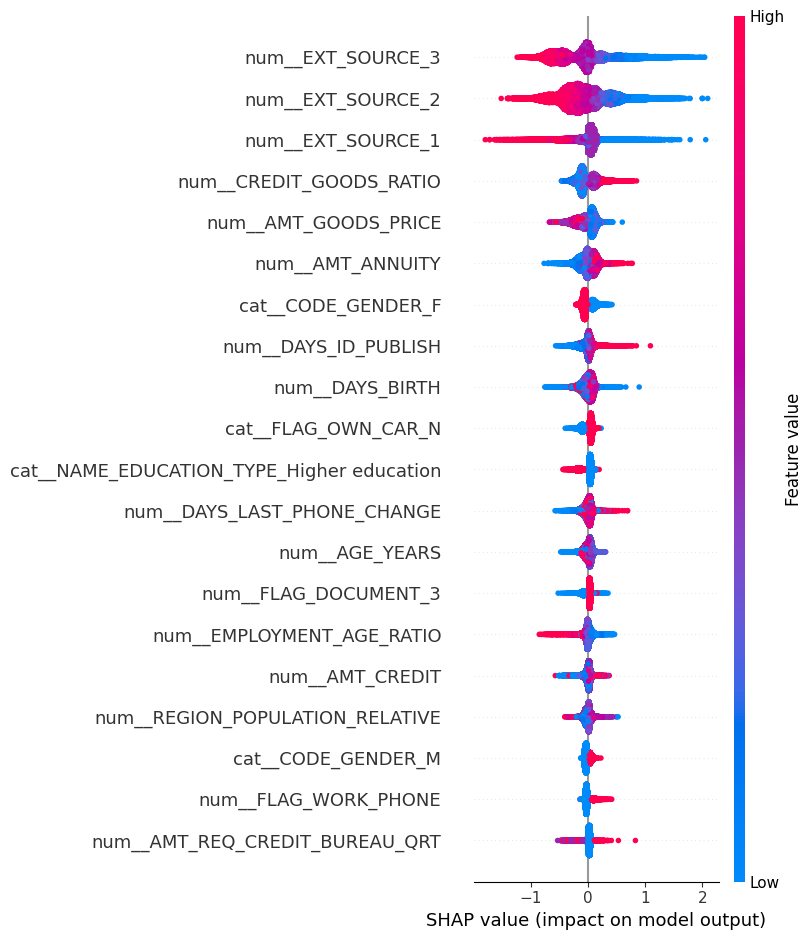

In [38]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

## Feature Importance (Bar Plot)

Display the average importance of each feature.

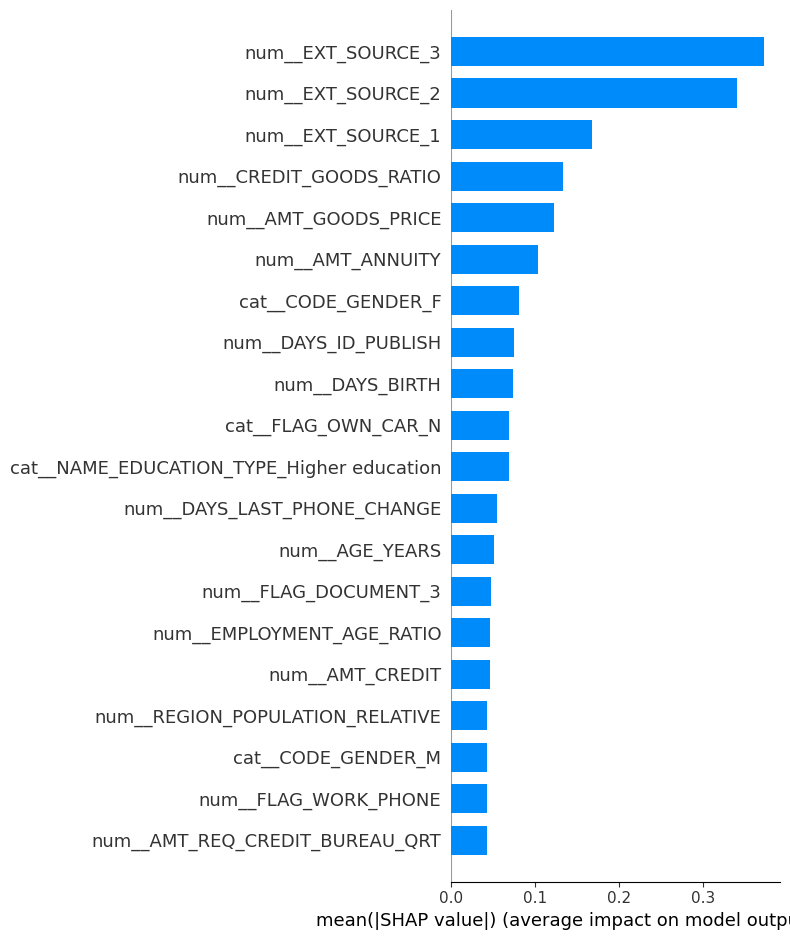

In [39]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

## Model Explainability Summary

### Key Findings

- EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 are the most influential features.
- Financial features such as credit amount, goods price, and annuity contribute significantly.
- Engineered features like `CREDIT_GOODS_RATIO` and `CREDIT_INCOME_RATIO` were useful.
- SHAP provides transparent explanations for model predictions, improving interpretability.

## Save Best Model

Save the trained XGBoost model so it can be loaded later for predictions without retraining.

In [40]:
import joblib

In [41]:
import os

os.makedirs("../models", exist_ok=True)

In [42]:
joblib.dump(xgb_model, "../models/best_model.pkl")

['../models/best_model.pkl']

Accuracy : 0.9195
Precision: 0.5213
Recall   : 0.0419
F1 Score : 0.0776
ROC AUC  : 0.7503


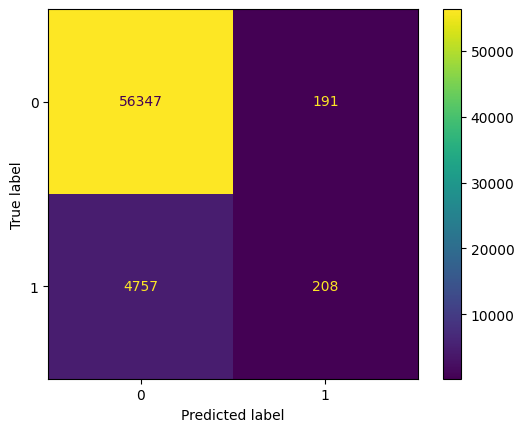

In [43]:
loaded_model = joblib.load("../models/best_model.pkl")

evaluate_model(loaded_model, X_test, y_test)

## Save Model Summary

The trained XGBoost pipeline was saved using Joblib.

This allows the model to be reused for inference without retraining.

In [44]:
top_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CREDIT_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "EMPLOYMENT_AGE_RATIO"
]

## Final Model for Deployment

Train a lightweight XGBoost model using the most important features identified by SHAP.

This simplifies deployment while maintaining good predictive performance.

In [45]:
X_small = df[top_features]
y_small = df["TARGET"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

In [47]:
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X_train.select_dtypes(
    include="object"
).columns

In [48]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols)
])

In [49]:
deployment_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [50]:
deployment_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CREDIT_INCOME_RATIO',
       'CREDIT_GOODS_RATIO', 'EMPLOYMENT_AGE_RATIO'],
      dtype='object'))])),
                ('classifier',
                 XGBClassifier(b...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy : 0.9191
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC AUC  : 0.6515


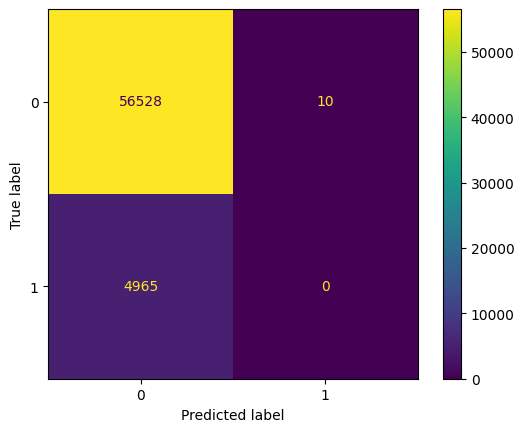

In [51]:
evaluate_model(deployment_model, X_test, y_test)

In [52]:
joblib.dump(deployment_model, "../models/deployment_model.pkl")

['../models/deployment_model.pkl']

In [53]:
print(X_small.columns.tolist())

['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CREDIT_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'EMPLOYMENT_AGE_RATIO']


In [54]:
deployment_model.named_steps["classifier"].feature_importances_

array([0.06867482, 0.09275326, 0.15188591, 0.10757418, 0.09584116,
       0.16468981, 0.0851215 , 0.16408251, 0.06937685], dtype=float32)